# Ibbotson–Sinquefield model — EDA

Exploration of the annual building blocks from Shiller's data (`data/ie_data.xlsx`, sheet `Data2`), AR(1) fits of inflation and the real short rate per sample period, and the bootstrap matrix $[e^\pi\ e^r\ tp\ erp]$.

**Output of this notebook:** the choice of the AR(1) and bootstrap periods and of `erp_target` for `issm_report.qmd`.

All series are annual log returns, Dec→Dec, 1935–2025 (see `ISSM-plan.md`), shown **in percent** (the loader's decimals × 100); `cape` stays a level. AR(1) constants, σ and residuals are therefore in percentage points too, while φ, R², correlations, skewness and kurtosis are unit-free.

## Setup

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using MacroFinanceScenarios
using MacroFinanceScenarios.IbbotsonSinquefield
using MacroFinanceScenarios.EDA
using DataFrames, Dates, GLM, Statistics, StatsBase, TimeSeries
using Distributions: Chisq, ccdf
using Plots, StatsPlots

# Render the EDA tables as HTML in the notebook.
show_table(t; title = "", digits = 2) =
    display(HTML(sprint(io -> print_table(io, t; backend = :html, digits, title))))

  Activating project at `~/projects/MacroFinanceScenarios`
[ Info: Precompiling MacroFinanceScenarios [855219de-e5b9-4c44-9d68-0e4839ca4f75] (cache misses: wrong dep version loaded (2), wrong source (2), mismatched flags (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling GLM [38e38edf-8417-5370-95a0-9cbb8c7f171a] (ca

show_table (generic function with 1 method)

## 1. Load data

Annual series, timestamped at 31 December of each year:

- `π`      inflation, `log(CPI_Dec,t / CPI_Dec,t-1)`
- `rf`     T-bill return, `log(1 + TBILL_Dec,t-1)`: the 3m yield at the start of the year
           rolled forward for the whole year (approximation: ignores the reinvestment at
           the 3m rates during the year)
- `r`      ex-post real short rate, `rf − π`
- `rb`     10y par-bond return from GS10 (`calculate_bond_returns`, annual step), in logs
- `tp`     term premium, `rb − rf`
- `re`     equity total return, `log((P_Dec,t + D_t) / P_Dec,t-1)` with `D_t` the sum of
           monthly D/12 over the year
- `xr`     equity excess return, `re − rf`
- `cape`   CAPE level in December
- `dlcape` `Δlog CAPE`
- `erp`    valuation-corrected equity premium, `xr − dlcape`

After loading, every series except `cape` is multiplied by 100 (percent).

In [2]:
raw = load_shiller_annual(joinpath(@__DIR__, "..", "..", "data", "ie_data.xlsx"))

# Percent units: returns and rates × 100; the CAPE level is left unchanged.
scale = [name == :cape ? 1.0 : 100.0 for name in colnames(raw)]
data = TimeArray(timestamp(raw), values(raw) .* scale', colnames(raw))
first(DataFrame(data), 5)

Row,timestamp,π,rf,r,rb,tp,re,xr,cape,dlcape,erp
,Date,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1935-12-31,2.94139,0.229736,-2.71165,3.97723,3.74749,37.6121,37.3824,16.1592,32.8099,36.038
2,1936-12-31,1.43887,0.149888,-1.28899,2.50416,2.35427,30.1817,30.0318,21.1257,26.7999,28.6874
3,1937-12-31,2.81709,0.119928,-2.69716,3.47527,3.35534,-36.8355,-36.9554,13.0085,-48.4887,-38.2998
4,1938-12-31,-2.81709,0.10994,2.92703,4.04527,3.93533,19.4547,19.3448,15.7565,19.165,18.0004
5,1939-12-31,0.0,0.0299955,0.0299955,3.56368,3.53368,1.78332,1.75333,16.2804,3.27107,0.408957


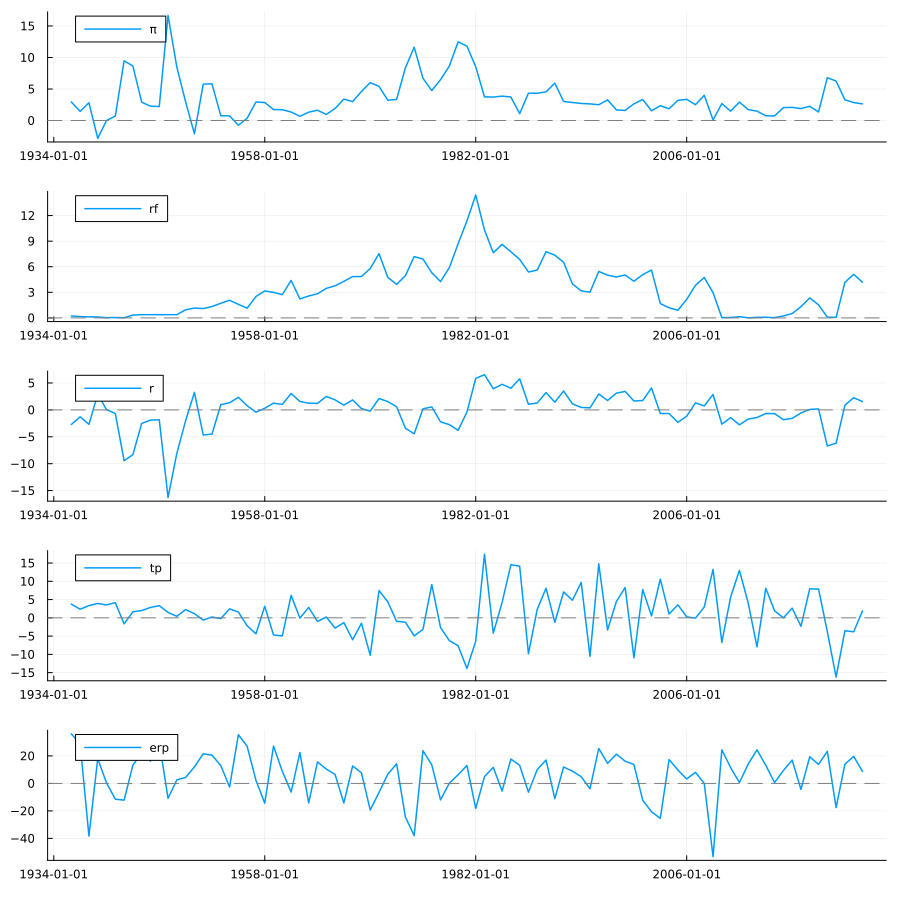

In [3]:
plot(data[:π, :rf, :r, :tp, :erp]; layout = (5, 1), size = (900, 900), legend = :topleft, lw = 1.5)
hline!(zeros(1, 5); color = :gray, ls = :dash, label = "")

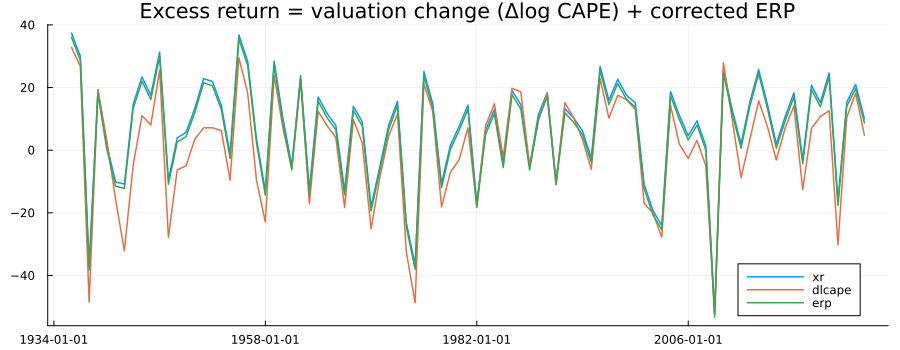

In [4]:
plot(data[:xr, :dlcape, :erp]; size = (900, 350), lw = 1.5,
     title = "Excess return = valuation change (Δlog CAPE) + corrected ERP")

## 2. Sample periods

The AR(1) window and the bootstrap window are chosen independently in the report; here each period is explored on its own.

In [5]:
periods = [
    :full     => (1935, 2025),
    :pre1975  => (1935, 1974),
    :post1975 => (1975, 2025),
]
eda_vars = [:π, :r, :rf, :tp, :xr, :dlcape, :erp]

7-element Vector{Symbol}:
 :π
 :r
 :rf
 :tp
 :xr
 :dlcape
 :erp

### Moments per period

In [6]:
for (name, p) in periods
    show_table(describe_series(subperiod(data, p)[eda_vars...]); title = "$name $(p[1])–$(p[2])")
end

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">full 1935–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">3.5</td>\n      <td style = \"text-align: right;\">3.13</td>\n      <td style = \"text-align: right;\">1.55</td>\n      <td style = \"text-align: right;\">3.42</td>\n      <td style = \"text-align: right;\">0.53</td>\n      <td style = \"text-align: right;\">-2.82</td>\n      <td style = \"text-align: right;\">1.66</td>\n      <td style = \"text-align: right;\">2.86</td>\n      <td style = \"text-align: right;\">4.33</td>\n      <td style = \"text-align: right;\">16.66</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">-0.14</td>\n      <td style = \"text-align: right;\">3.46</td>\n      <td style = \"text-align: right;\">-1.5</td>\n      <td style = \"text-align: right;\">4.56</td>\n      <td style = \"text-align: right;\">0.55</td>\n      <td style = \"text-align: right;\">-16.28</td>\n      <td style = \"text-align: right;\">-1.77</td>\n      <td style = \"text-align: right;\">0.46</td>\n      <td style = \"text-align: right;\">1.74</td>\n      <td style = \"text-align: right;\">6.54</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">3.36</td>\n      <td style = \"text-align: right;\">2.98</td>\n      <td style = \"text-align: right;\">0.96</td>\n      <td style = \"text-align: right;\">1.01</td>\n      <td style = \"text-align: right;\">0.89</td>\n      <td style = \"text-align: right;\">0.01</td>\n      <td style = \"text-align: right;\">0.44</td>\n      <td style = \"text-align: right;\">2.99</td>\n      <td style = \"text-align: right;\">5.05</td>\n      <td style = \"text-align: right;\">14.4</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">1.14</td>\n      <td style = \"text-align: right;\">6.38</td>\n      <td style = \"text-align: right;\">0.01</td>\n      <td style = \"text-align: right;\">0.32</td>\n      <td style = \"text-align: right;\">-0.06</td>\n      <td style = \"text-align: right;\">-16.22</td>\n      <td style = \"text-align: right;\">-2.73</td>\n      <td st

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">pre1975 1935–1974</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">3.39</td>\n      <td style = \"text-align: right;\">3.76</td>\n      <td style = \"text-align: right;\">1.42</td>\n      <td style = \"text-align: right;\">2.59</td>\n      <td style = \"text-align: right;\">0.36</td>\n      <td style = \"text-align: right;\">-2.82</td>\n      <td style = \"text-align: right;\">1.23</td>\n      <td style = \"text-align: right;\">2.84</td>\n      <td style = \"text-align: right;\">4.81</td>\n      <td style = \"text-align: right;\">16.66</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">-1.07</td>\n      <td style = \"text-align: right;\">3.98</td>\n      <td style = \"text-align: right;\">-1.85</td>\n      <td style = \"text-align: right;\">3.92</td>\n      <td style = \"text-align: right;\">0.48</td>\n      <td style = \"text-align: right;\">-16.28</td>\n      <td style = \"text-align: right;\">-2.58</td>\n      <td style = \"text-align: right;\">0.27</td>\n      <td style = \"text-align: right;\">1.38</td>\n      <td style = \"text-align: right;\">3.25</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">2.32</td>\n      <td style = \"text-align: right;\">2.09</td>\n      <td style = \"text-align: right;\">0.74</td>\n      <td style = \"text-align: right;\">-0.33</td>\n      <td style = \"text-align: right;\">0.83</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">0.38</td>\n      <td style = \"text-align: right;\">1.89</td>\n      <td style = \"text-align: right;\">3.81</td>\n      <td style = \"text-align: right;\">7.53</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">0.4</td>\n      <td style = \"text-align: right;\">3.57</td>\n      <td style = \"text-align: right;\">-0.68</td>\n      <td style = \"text-align: right;\">0.61</td>\n      <td style = \"text-align: right;\">0.06</td>\n      <td style = \"text-align: right;\">-10.26</td>\n      <td style = \"text-align: right;\">-1.34</td>\n      <

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">post1975 1975–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">3.59</td>\n      <td style = \"text-align: right;\">2.56</td>\n      <td style = \"text-align: right;\">1.73</td>\n      <td style = \"text-align: right;\">3.11</td>\n      <td style = \"text-align: right;\">0.72</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">1.97</td>\n      <td style = \"text-align: right;\">2.86</td>\n      <td style = \"text-align: right;\">4.16</td>\n      <td style = \"text-align: right;\">12.48</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">0.59</td>\n      <td style = \"text-align: right;\">2.82</td>\n      <td style = \"text-align: right;\">-0.19</td>\n      <td style = \"text-align: right;\">0.14</td>\n      <td style = \"text-align: right;\">0.61</td>\n      <td style = \"text-align: right;\">-6.71</td>\n      <td style = \"text-align: right;\">-1.31</td>\n      <td style = \"text-align: right;\">0.55</td>\n      <td style = \"text-align: right;\">2.56</td>\n      <td style = \"text-align: right;\">6.54</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">4.18</td>\n      <td style = \"text-align: right;\">3.32</td>\n      <td style = \"text-align: right;\">0.66</td>\n      <td style = \"text-align: right;\">0.34</td>\n      <td style = \"text-align: right;\">0.87</td>\n      <td style = \"text-align: right;\">0.01</td>\n      <td style = \"text-align: right;\">1.25</td>\n      <td style = \"text-align: right;\">4.26</td>\n      <td style = \"text-align: right;\">5.75</td>\n      <td style = \"text-align: right;\">14.4</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">1.72</td>\n      <td style = \"text-align: right;\">7.91</td>\n      <td style = \"text-align: right;\">-0.12</td>\n      <td style = \"text-align: right;\">-0.59</td>\n      <td style = \"text-align: right;\">-0.1</td>\n      <td style = \"text-align: right;\">-16.22</td>\n      <td style = \"text-align: right;\">-3.65</td>\n      <t

### Correlations per period

In [7]:
for (name, p) in periods
    show_table(correlation_table(subperiod(data, p)[eda_vars...]); title = "$name $(p[1])–$(p[2])", digits = 2)
end

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"8\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">full 1935–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">π</th>\n      <th style = \"font-weight: bold; text-align: right;\">r</th>\n      <th style = \"font-weight: bold; text-align: right;\">rf</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n      <th style = \"font-weight: bold; text-align: right;\">dlcape</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.59</td>\n      <td style = \"text-align: right;\">0.36</td>\n      <td style = \"text-align: right;\">-0.34</td>\n      <td style = \"text-align: right;\">-0.27</td>\n      <td style = \"text-align: right;\">-0.37</td>\n      <td style = \"text-align: right;\">-0.27</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">-0.59</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.54</td>\n      <td style = \"text-align: right;\">0.27</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">0.3</td>\n      <td style = \"text-align: right;\">0.09</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">0.36</td>\n      <td style = \"text-align: right;\">0.54</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">-0.18</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">-0.18</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.34</td>\n      <td style = \"text-align: right;\">0.27</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">0.02</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">-0.27</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">-0.18</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.96</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">dlcape</td>\n      <td style = \"text-align: right;\">-0.37</td>\n      <td style = \"text-align: right;\">0.3</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">0.96</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td styl

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"8\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">pre1975 1935–1974</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">π</th>\n      <th style = \"font-weight: bold; text-align: right;\">r</th>\n      <th style = \"font-weight: bold; text-align: right;\">rf</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n      <th style = \"font-weight: bold; text-align: right;\">dlcape</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.86</td>\n      <td style = \"text-align: right;\">0.17</td>\n      <td style = \"text-align: right;\">-0.21</td>\n      <td style = \"text-align: right;\">-0.44</td>\n      <td style = \"text-align: right;\">-0.57</td>\n      <td style = \"text-align: right;\">-0.44</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">-0.86</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.36</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">0.39</td>\n      <td style = \"text-align: right;\">0.21</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">0.17</td>\n      <td style = \"text-align: right;\">0.36</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.34</td>\n      <td style = \"text-align: right;\">-0.38</td>\n      <td style = \"text-align: right;\">-0.28</td>\n      <td style = \"text-align: right;\">-0.38</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.21</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">-0.34</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.08</td>\n      <td style = \"text-align: right;\">0.11</td>\n      <td style = \"text-align: right;\">0.08</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">-0.44</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">-0.38</td>\n      <td style = \"text-align: right;\">0.08</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.97</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">dlcape</td>\n      <td style = \"text-align: right;\">-0.57</td>\n      <td style = \"text-align: right;\">0.39</td>\n      <td style = \"text-align: right;\">-0.28</td>\n      <td style = \"text-align: right;\">0.11</td>\n      <td style = \"text-align: right;\">0.97</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"8\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">post1975 1975–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">π</th>\n      <th style = \"font-weight: bold; text-align: right;\">r</th>\n      <th style = \"font-weight: bold; text-align: right;\">rf</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n      <th style = \"font-weight: bold; text-align: right;\">dlcape</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.24</td>\n      <td style = \"text-align: right;\">0.57</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">-0.1</td>\n      <td style = \"text-align: right;\">-0.04</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">-0.24</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.66</td>\n      <td style = \"text-align: right;\">0.42</td>\n      <td style = \"text-align: right;\">-0.08</td>\n      <td style = \"text-align: right;\">0.13</td>\n      <td style = \"text-align: right;\">-0.08</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">rf</td>\n      <td style = \"text-align: right;\">0.57</td>\n      <td style = \"text-align: right;\">0.66</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.02</td>\n      <td style = \"text-align: right;\">-0.1</td>\n      <td style = \"text-align: right;\">0.03</td>\n      <td style = \"text-align: right;\">-0.1</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">0.42</td>\n      <td style = \"text-align: right;\">-0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">0.08</td>\n      <td style = \"text-align: right;\">0.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">-0.08</td>\n      <td style = \"text-align: right;\">-0.1</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.96</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">dlcape</td>\n      <td style = \"text-align: right;\">-0.1</td>\n      <td style = \"text-align: right;\">0.13</td>\n      <td style = \"text-align: right;\">0.03</td>\n      <td style = \"text-align: right;\">0.08</td>\n      <td style = \"text-align: right;\">0.96</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style

## 3. AR(1) fits of π and r

$x_t = c + \phi\, x_{t-1} + e_t$, estimated by OLS on each period. The first year of a period is lost to the lag.

In [8]:
function fit_ar1_glm(ta::TimeArray, var::Symbol)
    x = values(ta[var])
    df = DataFrame(year = year.(timestamp(ta))[2:end], x = x[2:end], x_lag = x[1:end-1])
    return (model = lm(@formula(x ~ x_lag), df), years = df.year, x = df.x)
end

ar_fits = Dict((name, var) => fit_ar1_glm(subperiod(data, p), var)
               for (name, p) in periods for var in (:π, :r))

Dict{Tuple{Symbol, Symbol}, @NamedTuple{model::StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}, years::Vector{Int64}, x::Vector{Float64}}} with 6 entries:
  (:pre1975, :π)  => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…
  (:full, :r)     => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…
  (:pre1975, :r)  => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…
  (:post1975, :r) => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…
  (:full, :π)     => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…
  (:post1975, :π) => (model = TableRegressionModel{LinearModel{LmResp{Vector{Fl…

In [9]:
for (name, p) in periods, var in (:π, :r)
    m = ar_fits[(name, var)].model
    println("── $var, $name $(p[1])–$(p[2])  (n = $(Int(nobs(m))), R² = $(round(r2(m), digits = 3)), σ = $(round(sqrt(deviance(m) / dof_residual(m)), digits = 4)))")
    display(coeftable(m))
end

── π, full 1935–2025  (n = 90, R² = 0.278, σ = 2.6859)


|             |    Coef. | Std. Error |    t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|---------:|-----------:|-----:|:---------|:----------|----------:|
| (Intercept) | 1.65553  |  0.425788  | 3.89 |   0.0002 |  0.809362 |  2.50169 |
| x_lag       | 0.527428 |  0.0905983 | 5.82 |   <1e-07 |  0.347382 |  0.707473 |

── r, full 1935–2025  (n = 90, R² = 0.305, σ = 2.9069)


|             |      Coef. | Std. Error |     t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|-----------:|-----------:|------:|:---------|:----------|----------:|
| (Intercept) | -0.0225611 |  0.30672   | -0.07 |   0.9415 | -0.632103 |  0.586981 |
| x_lag       |  0.551083  |  0.0887226 |  6.21 |   <1e-07 |  0.374766 |  0.727401 |

── π, pre1975 1935–1974  (n = 39, R² = 0.15, σ = 3.5584)


...

|             |     Coef. | Std. Error |     t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|----------:|-----------:|------:|:---------|:----------|----------:|
| (Intercept) | -0.549424 |   0.589464 | -0.93 |   0.3573 |  -1.74379 |  0.644944 |
| x_lag       |  0.485123 |   0.14514  |  3.34 |   0.0019 |   0.19104 |  0.779205 |

── π, post1975 1975–2025  (n = 50, R² = 0.54, σ = 1.7438)


|             |    Coef. | Std. Error |    t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|---------:|-----------:|-----:|:---------|:----------|----------:|
| (Intercept) | 0.911532 |  0.426815  | 2.14 |   0.0378 | 0.0533627 |  1.7697 |
| x_lag       | 0.725006 |  0.0964882 | 7.51 |   <1e-08 | 0.531004  |  0.919009 |

── r, post1975 1975–2025  (n = 50, R² = 0.378, σ = 2.2683)


|             |    Coef. | Std. Error |    t | Pr(>|t|) | Lower 95% | Upper 95% |
|:------------|---------:|-----------:|-----:|:---------|:----------|----------:|
| (Intercept) | 0.247714 |   0.327387 | 0.76 |   0.4530 | -0.410541 |  0.90597 |
| x_lag       | 0.61512  |   0.113975 | 5.40 |   <1e-05 |  0.385957 |  0.844282 |

### Side-by-side comparison

Unconditional mean $c/(1-\phi)$ and std $\sigma/\sqrt{1-\phi^2}$ implied by the fit, next to the sample moments of the period.

In [10]:
ar_summary = DataFrame(map(Iterators.product((:π, :r), periods)) do (var, (name, p))
    fit = ar_fits[(name, var)]
    c, φ = coef(fit.model)
    se_c, se_φ = stderror(fit.model)
    σ = sqrt(deviance(fit.model) / dof_residual(fit.model))
    x = values(subperiod(data, p)[var])
    (variable = String(var), period = String(name), years = "$(p[1])–$(p[2])", n = Int(nobs(fit.model)),
     c = c, se_c = se_c, φ = φ, se_φ = se_φ, σ = σ, R² = r2(fit.model),
     uncond_mean = c / (1 - φ), sample_mean = mean(x),
     uncond_std = σ / sqrt(1 - φ^2), sample_std = std(x))
end |> vec)
show_table(ar_summary)

variable,period,years,n,c,se_c,φ,se_φ,σ,R²,uncond_mean,sample_mean,uncond_std,sample_std
String,String,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
π,full,1935–2025,90.0,1.66,0.43,0.53,0.09,2.69,0.28,3.5,3.5,3.16,3.13
r,full,1935–2025,90.0,-0.02,0.31,0.55,0.09,2.91,0.3,-0.05,-0.14,3.48,3.46
π,pre1975,1935–1974,39.0,2.08,0.77,0.41,0.16,3.56,0.15,3.55,3.39,3.91,3.76
r,pre1975,1935–1974,39.0,-0.55,0.59,0.49,0.15,3.57,0.23,-1.07,-1.07,4.09,3.98
π,post1975,1975–2025,50.0,0.91,0.43,0.73,0.1,1.74,0.54,3.31,3.59,2.53,2.56
r,post1975,1975–2025,50.0,0.25,0.33,0.62,0.11,2.27,0.38,0.64,0.59,2.88,2.82


## 4. Diagnostics: fitted vs actual, residuals, residual ACF, QQ plot

In [11]:
function ar_diagnostics(fit, title)
    e = residuals(fit.model)
    p1 = plot(fit.years, fit.x; label = "actual", lw = 1.5, title = "$title: fitted vs actual")
    plot!(p1, fit.years, fitted(fit.model); label = "fitted", lw = 1.5)
    p2 = bar(fit.years, e; label = "", title = "residuals", lw = 0)
    lags = 1:10
    band = 1.96 / sqrt(length(e))
    p3 = bar(lags, autocor(e, lags); label = "", title = "residual ACF", ylims = (-1, 1))
    hline!(p3, [band, -band]; color = :gray, ls = :dash, label = "±1.96/√n")
    p4 = qqnorm(e ./ std(e); title = "QQ (standardised)", markersize = 3, label = "")
    plot(p1, p2, p3, p4; layout = (2, 2), size = (900, 600))
end

ar_diagnostics (generic function with 1 method)

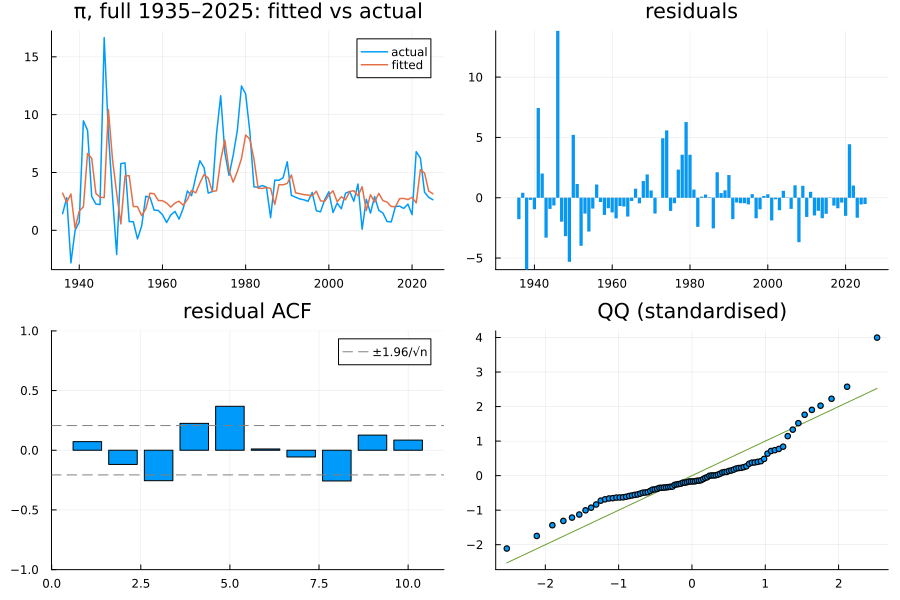

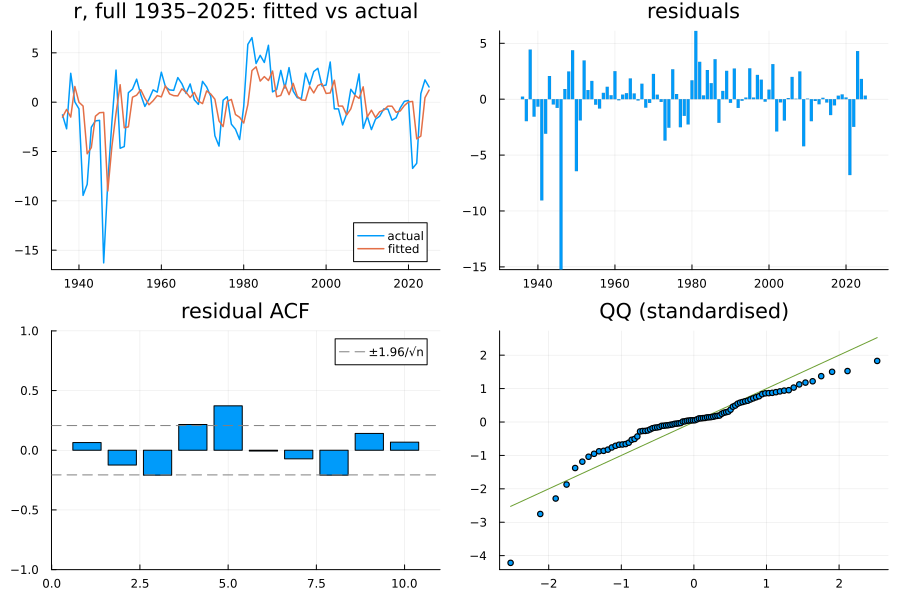

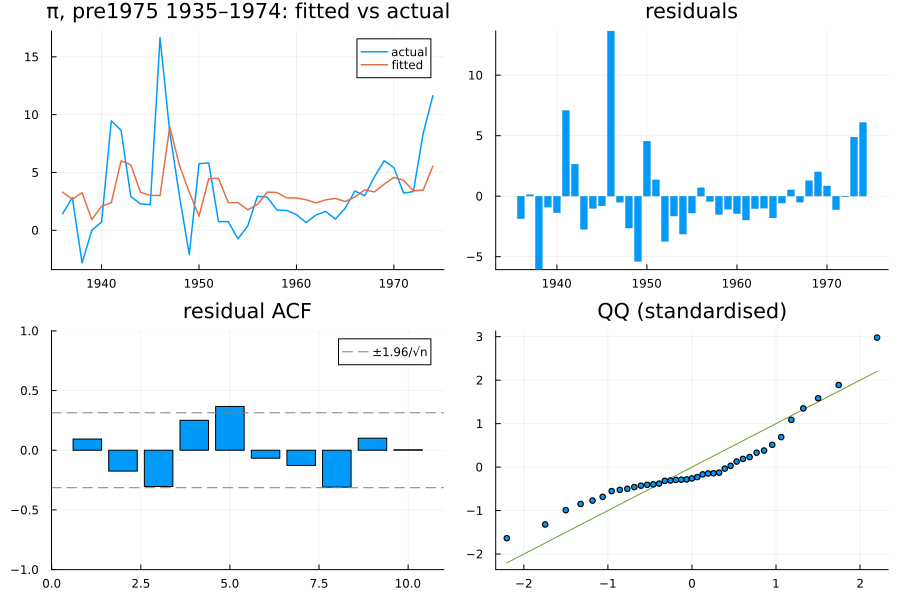

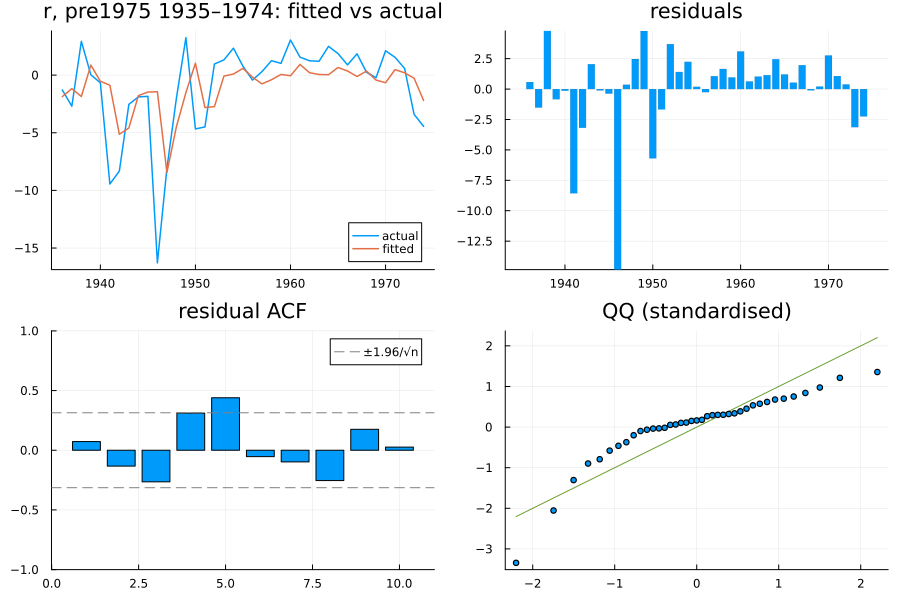

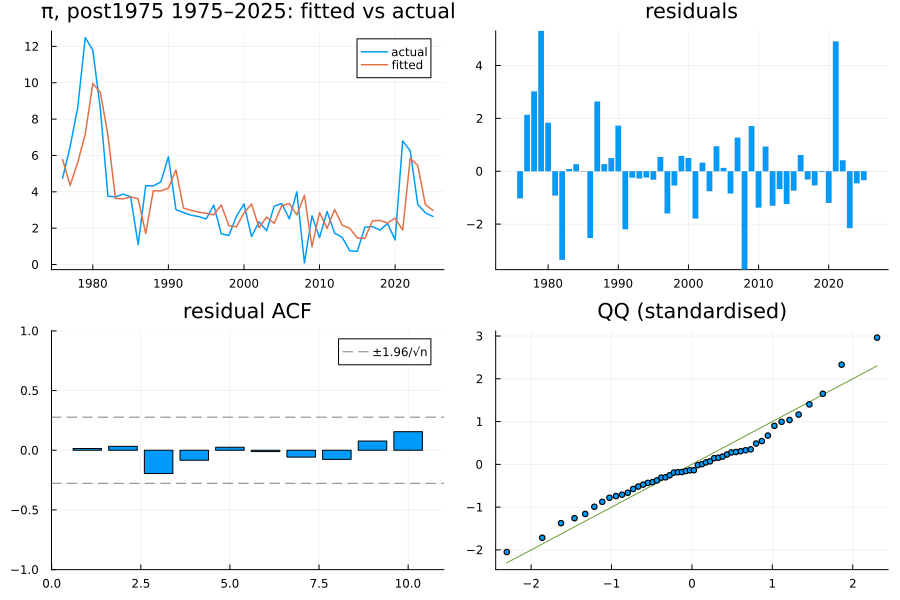

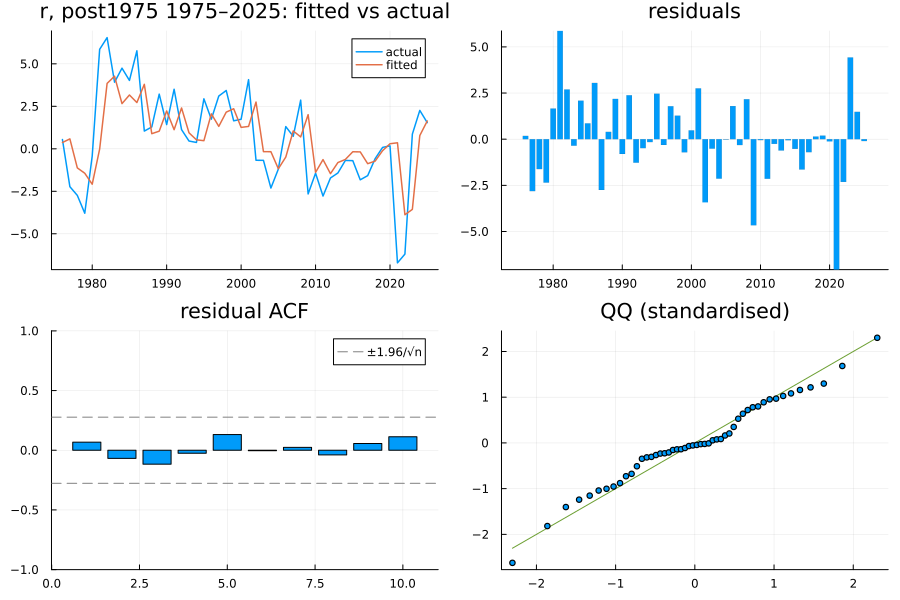

In [12]:
for (name, p) in periods, var in (:π, :r)
    display(ar_diagnostics(ar_fits[(name, var)], "$var, $name $(p[1])–$(p[2])"))
end

### Residual autocorrelation

The bootstrap draws years i.i.d., so all serial dependence must come from the AR(1)s: the residuals $e_t$ should be close to white noise. The table shows the residual autocorrelations at lags 1–5 (significant at 5% beyond ±`band` = $1.96/\sqrt{n}$) and the Ljung–Box test $Q(5) = n(n+2)\sum_{k=1}^{5} \hat\rho_k^2/(n-k)$, with 4 degrees of freedom for $e$ (one AR coefficient estimated).

The rows for $e^2$ check for volatility clustering (McLeod–Li, 5 degrees of freedom). The i.i.d. bootstrap cannot reproduce that either.

In [13]:
function ljung_box(x, h; fitted_params = 0)
    n = length(x)
    ρ = autocor(x, 1:h)
    Q = n * (n + 2) * sum(ρ[k]^2 / (n - k) for k in 1:h)
    return Q, ccdf(Chisq(h - fitted_params), Q)
end

acf_lags = 1:5
resid_acf = DataFrame([begin
    e = residuals(ar_fits[(name, var)].model)
    x = kind == "e" ? e : e .^ 2
    Q, pval = ljung_box(x, length(acf_lags); fitted_params = kind == "e" ? 1 : 0)
    merge((variable = String(var), series = kind, period = String(name), n = length(x)),
          NamedTuple{Tuple(Symbol.("lag", acf_lags))}(autocor(x, acf_lags)),
          (band = 1.96 / sqrt(length(x)), Q5 = Q, p_value = pval))
end for (name, p) in periods for var in (:π, :r) for kind in ("e", "e²")])
show_table(resid_acf; title = "Autocorrelation of AR(1) residuals")

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"12\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Autocorrelation of AR(1) residuals</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">series</th>\n      <th style = \"font-weight: bold; text-align: right;\">period</th>\n      <th style = \"font-weight: bold; text-align: right;\">n</th>\n      <th style = \"font-weight: bold; text-align: right;\">lag1</th>\n      <th style = \"font-weight: bold; text-align: right;\">lag2</th>\n      <th style = \"font-weight: bold; text-align: right;\">lag3</th>\n      <th style = \"font-weight: bold; text-align: right;\">lag4</th>\n      <th style = \"font-weight: bold; text-align: right;\">lag5</th>\n      <th style = \"font-weight: bold; text-align: right;\">band</th>\n      <th style = \"font-weight: bold; text-align: right;\">Q5</th>\n      <th style = \"font-weight: bold; text-align: right;\">p_value</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Int64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">e</td>\n      <td style = \"text-align: right;\">full</td>\n      <td style = \"text-align: right;\">90.0</td>\n      <td style = \"text-align: right;\">0.07</td>\n      <td style = \"text-align: right;\">-0.12</td>\n      <td style = \"text-align: right;\">-0.26</td>\n      <td style = \"text-align: right;\">0.23</td>\n      <td style = \"text-align: right;\">0.37</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">26.09</td>\n      <td style = \"text-align: right;\">0.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">π</td>\n      <td style = \"text-align: right;\">e²</td>\n      <td style = \"text-align: right;\">full</td>\n      <td style = \"text-align: right;\">90.0</td>\n      <td style = \"text-align: right;\">-0.0</td>\n      <td style = \"text-align: right;\">-0.0</td>\n      <td style = \"text-align: right;\">0.15</td>\n      <td style = \"text-align: right;\">0.07</td>\n      <td style = \"text-align: right;\">0.22</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">7.47</td>\n      <td style = \"text-align: right;\">0.19</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">e</td>\n      <td style = \"text-align: right;\">full</td>\n      <td style = \"text-align: right;\">90.0</td>\n      <td style = \"text-align: right;\">0.06</td>\n      <td style = \"text-align: right;\">-0.12</td>\n      <td style = \"text-align: right;\">-0.21</td>\n      <td style = \"text-align: right;\">0.22</td>\n      <td style = \"text-align: right;\">0.37</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">23.93</td>\n      <td style = \"text-align: right;\">0.0</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">r</td>\n      <td style = \"text-align: right;\">e²</td>\n      <td style = \"text-align: right;\">full

### Correlation of the AR(1) shocks with tp and xr

Contemporaneous correlations of the inflation and real-rate shocks ($e^\pi$, $e^r$) with the term premium and the raw equity excess return, on the same aligned years as the bootstrap matrix. The joint bootstrap preserves these correlations, so they determine how bond and equity returns react to inflation and real-rate surprises in the scenarios.

In [14]:
for (name, p) in periods
    sub = subperiod(data, p)[2:end]          # align with the AR residuals
    shocks = TimeArray(timestamp(sub),
                       hcat(residuals(ar_fits[(name, :π)].model), residuals(ar_fits[(name, :r)].model),
                            values(sub[:tp]), values(sub[:xr])),
                       [:eπ, :er, :tp, :xr])
    show_table(correlation_table(shocks); title = "AR(1) shocks vs tp, xr — $name $(p[1])–$(p[2])")
end

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">AR(1) shocks vs tp, xr — full 1935–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.81</td>\n      <td style = \"text-align: right;\">-0.32</td>\n      <td style = \"text-align: right;\">-0.27</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.81</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">0.15</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.32</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.02</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">-0.27</td>\n      <td style = \"text-align: right;\">0.15</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">AR(1) shocks vs tp, xr — pre1975 1935–1974</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.93</td>\n      <td style = \"text-align: right;\">-0.23</td>\n      <td style = \"text-align: right;\">-0.46</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.93</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.12</td>\n      <td style = \"text-align: right;\">0.29</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.23</td>\n      <td style = \"text-align: right;\">0.12</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.04</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">-0.46</td>\n      <td style = \"text-align: right;\">0.29</td>\n      <td style = \"text-align: right;\">0.04</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">AR(1) shocks vs tp, xr — post1975 1975–2025</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">xr</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.69</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">0.1</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.69</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.28</td>\n      <td style = \"text-align: right;\">-0.07</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">0.28</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.02</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">xr</td>\n      <td style = \"text-align: right;\">0.1</td>\n      <td style = \"text-align: right;\">-0.07</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

## 5. Bootstrap matrix $[e^\pi\ e^r\ tp\ erp]$

Rows are years; the residuals and the premia come from the **same years**, so the first year of the period (lost to the AR lag) is dropped from tp and erp too. Here the residuals come from the AR fit on the same period; in the report the two windows can differ.

In [15]:
function bootstrap_table(data::TimeArray, name, p)
    sub = subperiod(data, p)[2:end]          # align with the AR residuals
    eπ = residuals(ar_fits[(name, :π)].model)
    er = residuals(ar_fits[(name, :r)].model)
    return TimeArray(timestamp(sub), hcat(eπ, er, values(sub[:tp]), values(sub[:erp])),
                     [:eπ, :er, :tp, :erp])
end

boot = Dict(name => bootstrap_table(data, name, p) for (name, p) in periods)
for (name, p) in periods
    show_table(describe_series(boot[name]); title = "Bootstrap matrix moments — $name")
    show_table(correlation_table(boot[name]); title = "Bootstrap matrix correlations — $name", digits = 2)
end

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix moments — full</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">2.67</td>\n      <td style = \"text-align: right;\">1.96</td>\n      <td style = \"text-align: right;\">7.57</td>\n      <td style = \"text-align: right;\">0.07</td>\n      <td style = \"text-align: right;\">-5.96</td>\n      <td style = \"text-align: right;\">-1.32</td>\n      <td style = \"text-align: right;\">-0.45</td>\n      <td style = \"text-align: right;\">0.6</td>\n      <td style = \"text-align: right;\">13.84</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">2.89</td>\n      <td style = \"text-align: right;\">-2.01</td>\n      <td style = \"text-align: right;\">8.23</td>\n      <td style = \"text-align: right;\">0.06</td>\n      <td style = \"text-align: right;\">-15.25</td>\n      <td style = \"text-align: right;\">-0.77</td>\n      <td style = \"text-align: right;\">0.15</td>\n      <td style = \"text-align: right;\">1.73</td>\n      <td style = \"text-align: right;\">6.11</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">1.11</td>\n      <td style = \"text-align: right;\">6.41</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">0.3</td>\n      <td style = \"text-align: right;\">-0.06</td>\n      <td style = \"text-align: right;\">-16.22</td>\n      <td style = \"text-align: right;\">-2.77</td>\n      <td style = \"text-align: right;\">1.32</td>\n      <td style = \"text-align: right;\">4.17</td>\n      <td style = \"text-align: right;\">17.4</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">5.52</td>\n      <td style = \"text-align: right;\">16.42</td>\n      <td style = \"text-align: right;\">-1.01</td>\n      <td style = \"text-align: right;\">1.16</td>\n      <td style = \"text-align: right;\">-0.06</td>\n      <td style = \"text-align: right;\">-53.32</td>\n      <td style = \"text-align: right;\"

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix correlations — full</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.81</td>\n      <td style = \"text-align: right;\">-0.32</td>\n      <td style = \"text-align: right;\">-0.27</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.81</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">0.15</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.32</td>\n      <td style = \"text-align: right;\">0.21</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.02</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">-0.27</td>\n      <td style = \"text-align: right;\">0.15</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix moments — pre1975</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">3.51</td>\n      <td style = \"text-align: right;\">1.74</td>\n      <td style = \"text-align: right;\">4.55</td>\n      <td style = \"text-align: right;\">0.09</td>\n      <td style = \"text-align: right;\">-6.07</td>\n      <td style = \"text-align: right;\">-1.58</td>\n      <td style = \"text-align: right;\">-0.92</td>\n      <td style = \"text-align: right;\">0.78</td>\n      <td style = \"text-align: right;\">13.66</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">3.52</td>\n      <td style = \"text-align: right;\">-2.3</td>\n      <td style = \"text-align: right;\">6.92</td>\n      <td style = \"text-align: right;\">0.07</td>\n      <td style = \"text-align: right;\">-14.84</td>\n      <td style = \"text-align: right;\">-0.32</td>\n      <td style = \"text-align: right;\">0.58</td>\n      <td style = \"text-align: right;\">1.81</td>\n      <td style = \"text-align: right;\">4.78</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">0.32</td>\n      <td style = \"text-align: right;\">3.58</td>\n      <td style = \"text-align: right;\">-0.65</td>\n      <td style = \"text-align: right;\">0.6</td>\n      <td style = \"text-align: right;\">0.05</td>\n      <td style = \"text-align: right;\">-10.26</td>\n      <td style = \"text-align: right;\">-1.39</td>\n      <td style = \"text-align: right;\">0.42</td>\n      <td style = \"text-align: right;\">2.85</td>\n      <td style = \"text-align: right;\">7.46</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">4.78</td>\n      <td style = \"text-align: right;\">18.1</td>\n      <td style = \"text-align: right;\">-0.57</td>\n      <td style = \"text-align: right;\">-0.23</td>\n      <td style = \"text-align: right;\">-0.03</td>\n      <td style = \"text-align: right;\">-38.3</td>\n      <td style = \"text-align: right;

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix correlations — pre1975</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.93</td>\n      <td style = \"text-align: right;\">-0.23</td>\n      <td style = \"text-align: right;\">-0.46</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.93</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.12</td>\n      <td style = \"text-align: right;\">0.29</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.23</td>\n      <td style = \"text-align: right;\">0.12</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.04</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">-0.46</td>\n      <td style = \"text-align: right;\">0.29</td>\n      <td style = \"text-align: right;\">0.04</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"11\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix moments — post1975</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">mean</th>\n      <th style = \"font-weight: bold; text-align: right;\">std</th>\n      <th style = \"font-weight: bold; text-align: right;\">skewness</th>\n      <th style = \"font-weight: bold; text-align: right;\">ex_kurtosis</th>\n      <th style = \"font-weight: bold; text-align: right;\">ar1</th>\n      <th style = \"font-weight: bold; text-align: right;\">min</th>\n      <th style = \"font-weight: bold; text-align: right;\">p25</th>\n      <th style = \"font-weight: bold; text-align: right;\">p50</th>\n      <th style = \"font-weight: bold; text-align: right;\">p75</th>\n      <th style = \"font-weight: bold; text-align: right;\">max</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">1.73</td>\n      <td style = \"text-align: right;\">0.79</td>\n      <td style = \"text-align: right;\">1.68</td>\n      <td style = \"text-align: right;\">0.01</td>\n      <td style = \"text-align: right;\">-3.72</td>\n      <td style = \"text-align: right;\">-0.9</td>\n      <td style = \"text-align: right;\">-0.24</td>\n      <td style = \"text-align: right;\">0.57</td>\n      <td style = \"text-align: right;\">5.31</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">0.0</td>\n      <td style = \"text-align: right;\">2.25</td>\n      <td style = \"text-align: right;\">-0.29</td>\n      <td style = \"text-align: right;\">1.33</td>\n      <td style = \"text-align: right;\">0.07</td>\n      <td style = \"text-align: right;\">-7.07</td>\n      <td style = \"text-align: right;\">-0.78</td>\n      <td style = \"text-align: right;\">-0.11</td>\n      <td style = \"text-align: right;\">1.61</td>\n      <td style = \"text-align: right;\">5.87</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">1.82</td>\n      <td style = \"text-align: right;\">7.96</td>\n      <td style = \"text-align: right;\">-0.15</td>\n      <td style = \"text-align: right;\">-0.59</td>\n      <td style = \"text-align: right;\">-0.09</td>\n      <td style = \"text-align: right;\">-16.22</td>\n      <td style = \"text-align: right;\">-3.71</td>\n      <td style = \"text-align: right;\">2.12</td>\n      <td style = \"text-align: right;\">7.93</td>\n      <td style = \"text-align: right;\">17.4</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">5.72</td>\n      <td style = \"text-align: right;\">15.11</td>\n      <td style = \"text-align: right;\">-1.52</td>\n      <td style = \"text-align: right;\">3.1</td>\n      <td style = \"text-align: right;\">-0.04</td>\n      <td style = \"text-align: right;\">-53.32</td>\n      <td style = \"text-align: rig

HTML{String}("<table>\n  <thead>\n    <tr class = \"title\">\n      <td colspan = \"5\" style = \"font-size: x-large; font-weight: bold; text-align: center;\">Bootstrap matrix correlations — post1975</td>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"font-weight: bold; text-align: right;\">variable</th>\n      <th style = \"font-weight: bold; text-align: right;\">eπ</th>\n      <th style = \"font-weight: bold; text-align: right;\">er</th>\n      <th style = \"font-weight: bold; text-align: right;\">tp</th>\n      <th style = \"font-weight: bold; text-align: right;\">erp</th>\n    </tr>\n    <tr class = \"columnLabelRow\">\n      <th style = \"text-align: right;\">String</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n      <th style = \"text-align: right;\">Float64</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">eπ</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">-0.69</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">0.1</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">er</td>\n      <td style = \"text-align: right;\">-0.69</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.28</td>\n      <td style = \"text-align: right;\">-0.07</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">tp</td>\n      <td style = \"text-align: right;\">-0.49</td>\n      <td style = \"text-align: right;\">0.28</td>\n      <td style = \"text-align: right;\">1.0</td>\n      <td style = \"text-align: right;\">0.02</td>\n    </tr>\n    <tr class = \"dataRow\">\n      <td style = \"text-align: right;\">erp</td>\n      <td style = \"text-align: right;\">0.1</td>\n      <td style = \"text-align: right;\">-0.07</td>\n      <td style = \"text-align: right;\">0.02</td>\n      <td style = \"text-align: right;\">1.0</td>\n    </tr>\n  </tbody>\n</table>\n")

### Raw excess return vs valuation-corrected ERP

Input for choosing `erp_target`. The gap between the means of `xr` and `erp` is the average re-rating (mean Δlog CAPE), which should not be extrapolated.

In [16]:
erp_summary = DataFrame(map(periods) do (name, p)
    sub = subperiod(data, p)
    xr, dl, erp = values(sub[:xr]), values(sub[:dlcape]), values(sub[:erp])
    (period = String(name), years = "$(p[1])–$(p[2])",
     mean_xr = mean(xr), mean_dlcape = mean(dl), mean_erp = mean(erp),
     std_xr = std(xr), std_erp = std(erp),
     cape_start = values(sub[:cape])[1] / exp(dl[1] / 100), cape_end = values(sub[:cape])[end])
end)
show_table(erp_summary)

period,years,mean_xr,mean_dlcape,mean_erp,std_xr,std_erp,cape_start,cape_end
String,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
full,1935–2025,7.2,1.34,5.85,16.64,16.64,11.64,39.56
pre1975,1935–1974,6.91,-0.85,5.56,18.54,18.54,11.64,8.29
post1975,1975–2025,7.42,3.06,6.08,15.17,15.17,8.29,39.56


## Conclusions

Fill in after reviewing the tables above; these values go into the `params` of `issm_report.qmd`.

- AR(1) period (`ar_start`, `ar_end`): …
- Bootstrap period (`boot_start`, `boot_end`): …
- `erp_target`: … (in percent here; the report's `erp_target` is in decimals, so divide by 100)